# Does size-tightening the template via a "largest connected component" rule change anything?

**Purpose.** `tm_threshold_axis_sweep_v2.ipynb` ran the click-seeded `TM_CCOEFF` search with
zero bbox tightening -- every domain's template is the raw, fixed 51x51 annotation box
(`tm.BASE_SIZE`), centred on the click. This notebook re-runs the identical sweep with one
change: before matching, each seed's template is **size-refined** using a rule new to this
notebook -- Otsu-threshold a 51px structural crop around the click, take the **largest**
connected component in the crop (regardless of whether the click's own pixel lands inside it),
and use that component's native bounding-box size as the template's `base_size`. The template
stays centred on the click; only its size changes.

**Why "largest CC", not the click-aligned rule already in `midog_utils`.** Production bbox
tightening (`seed_selection.tighten_box_otsu` / `tightened_base_size`) requires the click's own
pixel to be foreground and takes *that* component -- refusing (returning `None`) an annotation
whose click misses its own object's mask, rather than falling back to anything else. A "largest
component in the crop, click-independent" fallback was explored once and explicitly **not**
adopted as production logic (`Research Logs/2026-08-25-bbox-tuning-domain-mismatch.md`,
Experiment 5): *"a weak heuristic ... in a crowded crop it can grab an unrelated, larger
structure instead of the annotated one."* This notebook runs that historically-rejected rule
as a deliberate, fully-aware experiment -- not a rediscovery -- to see what it actually does to
recall, candidate volume and TP/FP separability when it is run end-to-end rather than eyeballed
on one image.

**What is held fixed.** Channel (`hematoxylin_od`), method (`TM_CCOEFF`), the two border/NMS
fixes `tm_threshold_axis_sweep_v2.ipynb` verified (padding so the whole ROI is reachable;
NMS at a decoupled 5.0 um radius, separate from the ~7.5 um evaluation match radius), the
one-match-many-`z` pool-reuse shortcut, `DEEP_FLOOR_Z=-1.5`, the `Z_LEVELS` sweep,
`CURRENT_Z=1.0` (the operating point `tp_fp_score_distribution.ipynb` /
`tp_fp_chromatin_and_raw_score_distribution.ipynb` settled on -- **not** v2's own stale
`CURRENT_Z=0.5` config-cell comment), `peak_min_distance=7`, `self_hit_radius=5.0`, the
chromatin-density `od` re-ranking axis and its border-padding fix. The seed-selection *rule*
(pathologist-agreement pool, border filter, `rng = np.random.default_rng([0, image_id])`) is
identical to v2's -- the only new step is a size-tightening pass applied to whichever candidate
that rng draws, with a retry-on-failure mechanism (below) that this notebook's real data is not
expected to exercise, but which is built and unit-tested regardless.

**A structural note worth flagging up front.** The chromatin-density `od` signal reads a fixed
51px window regardless of the (now possibly smaller) match template -- so the padding margin
that keeps the *match* reachable everywhere (`PAD`, tied to the template size) is no longer the
same margin that keeps `od` NaN-free (tied to the fixed 51px window). This notebook gives `od`
its own, independent padding constant rather than reusing `PAD` -- reusing it would silently
NaN every candidate inside a shrunken-`PAD` border margin, a bug v2 and the two TP/FP notebooks
never hit only because their template (hence `PAD`) always happened to be exactly 51px too.
See the chromatin section below for the assertion that catches this if it's ever wrong.


In [1]:
import time
NB_T0 = time.time()

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops

from midog_utils import chromatin as cm
from midog_utils import channels as ch
from midog_utils import compare as cp
from midog_utils import dataset as ds
from midog_utils import evaluate as ev
from midog_utils import experiment as ex
from midog_utils import find_and_suppress as fs
from midog_utils import seed_selection as ss
from midog_utils import template_match as tm
from midog_utils.nms import nms_by_distance
from sklearn.neighbors import KDTree

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
print('imports ok')

imports ok


## Configuration -- identical to v2 except `CURRENT_Z` and the new tightening knobs

Everything else (channel, method, `Z_LEVELS`, `DEEP_FLOOR_Z`, the two decoupled radii,
`peak_min_distance`, `self_hit_radius`) is copied from `tm_threshold_axis_sweep_v2.ipynb` /
`tp_fp_score_distribution.ipynb`, not re-derived, so any difference in the results is
attributable to the tightening rule and not to a config drift.

`OTSU_WINDOW = tm.BASE_SIZE = 51` -- the same window `seed_selection.foreground_filter` uses
by default (not `PATCH_SIZE=73`): a wider window saturates in dense tissue, bridging into
neighbouring nuclei before Otsu ever gets a chance to separate them (see `foreground_filter`'s
docstring and `BBOX_TUNING.md`). `LARGEST_CC_KW` uses the exact same sanity-gate defaults as
production `tighten_box_otsu` (`min_area=50, max_area_frac=0.85, min_solidity=0.5`) -- this
experiment is about the *selection rule*, not about re-tuning those gates.

In [2]:
CHANNEL = 'hematoxylin_od'
METHOD = cv2.TM_CCOEFF
PEAK_MIN_DISTANCE = 7
SEED_INDEX = 0
SELF_HIT_RADIUS = 5.0

Z_LEVELS = (-1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0)
CURRENT_Z = 1.0                                          # the operating point v2's own comment
                                                          # is stale on -- this matches the two
                                                          # TP/FP notebooks' actual decision.
DEEP_FLOOR_Z = min(Z_LEVELS) - 0.5
MAX_PEAKS = 2_000_000

NMS_RADIUS_UM = 5.0                                      # decoupled de-dup radius (v2's fix 2)
MATCH_RADIUS_UM = ev.MIDOG_RADIUS_UM                     # eval/scoring radius, unchanged

BUDGETS = cp.BUDGETS
AXES = ('tm_score', 'chromatin_od')
AXIS_RANK_KEY = {'tm_score': 'score', 'chromatin_od': 'od'}
AXIS_COLOR = {'tm_score': '#4c72b0', 'chromatin_od': '#c44e52'}

# CFG.base_size is a placeholder -- the actual per-domain base_size is computed from the
# largest-CC bbox below and passed explicitly to tm.build_augmentations; CFG only supplies
# patch_size (73, unchanged -- still the rotation-safe read radius regardless of template
# size), peak_min_distance and self_hit_radius.
CFG = fs.FSConfig(channel=CHANNEL, base_size=tm.BASE_SIZE, scales=(1.0,),
                  n_angles=1, flips=(False,), peak_min_distance=PEAK_MIN_DISTANCE,
                  self_hit_radius=SELF_HIT_RADIUS)
BORDER = CFG.patch_size // 2   # 36 -- unchanged: still the seed's own rotation-safe margin

OTSU_WINDOW = tm.BASE_SIZE                                # 51 -- foreground_filter's own default
LARGEST_CC_KW = dict(min_area=50, max_area_frac=0.85, min_solidity=0.5)  # == tighten_box_otsu's

FP_SUBSAMPLE_CAP = 8000
RNG_SEED = 0

BUCKET_COLOR = {ev.HUMAN_CORRECT_LABEL: '#2ca02c',
               ev.HUMAN_REJECTED_LABEL: '#ff7f0e',
               ev.NON_HUMAN_FINDINGS: '#7f7f7f'}
BUCKET_LABEL = {ev.HUMAN_CORRECT_LABEL: 'TP (mitotic)',
               ev.HUMAN_REJECTED_LABEL: 'FP -- look-alike',
               ev.NON_HUMAN_FINDINGS: 'FP -- unannotated'}
BUCKET_LANE = {ev.HUMAN_CORRECT_LABEL: 2, ev.HUMAN_REJECTED_LABEL: 1, ev.NON_HUMAN_FINDINGS: 0}
STYLE = {
    ev.NON_HUMAN_FINDINGS: dict(s=5, alpha=0.10, zorder=1),
    ev.HUMAN_REJECTED_LABEL: dict(s=10, alpha=0.35, zorder=2),
    ev.HUMAN_CORRECT_LABEL: dict(s=22, alpha=0.9, zorder=3, edgecolors='#145214', linewidths=0.3),
}
print('config ok')

config ok


## `largest_cc_box` -- implemented fresh, local to this notebook

Not added to `midog_utils/seed_selection.py`: that module has unrelated, concurrently in-flight
uncommitted changes for a different experiment (the Otsu-threshold-method sweep in
`Research Logs/2026-09-03-bbox-threshold-sweep.md`), and this rule was historically probed and
explicitly *not* adopted as production logic anyway -- it belongs local to the notebook that is
deliberately re-testing it, not in the production module.

Structurally this is `tighten_box_otsu`'s `method="binary"` path with only the
component-selection step changed: instead of requiring the click's own (rounded) pixel to be
foreground and taking *that* component, this takes the **largest** component in the crop by
area, unconditionally -- the click location never enters the computation at all.

In [3]:
def _odd_local(n: int, minimum: int = 5) -> int:
    n = int(round(n))
    if n % 2 == 0:
        n += 1
    return max(minimum, n)


def largest_cc_box(patch, min_area=50, max_area_frac=0.85, min_solidity=0.5):
    '''Otsu-threshold `patch` (channels.to_gray_inverted convention: 'more object -> higher
    value') and return the bbox of its LARGEST connected component by area, regardless of
    whether it contains the click. Returns (y0, y1, x0, x1), patch-local, half-open -- or
    None if no component exists, or the largest one fails the size/shape sanity gates.
    Deliberately does not reference the click location at all (contrast with
    seed_selection.tighten_box_otsu, which requires the click's own pixel to be foreground).'''
    if patch.ndim != 2:
        raise ValueError(f"largest_cc_box needs a single-channel patch, got shape {patch.shape}")
    u8 = cv2.normalize(patch.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, binary = cv2.threshold(u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    labels = label(binary, connectivity=2)
    regions = regionprops(labels)
    if not regions:
        return None
    largest = max(regions, key=lambda r: r.area)
    if largest.area < min_area:
        return None
    if largest.area > max_area_frac * patch.size:
        return None
    if largest.solidity < min_solidity:
        return None
    y0, x0, y1, x1 = largest.bbox
    return int(y0), int(y1), int(x0), int(x1)


print('largest_cc_box defined')

largest_cc_box defined


## Seed draw with retry-on-failure -- built and unit-tested, not assumed to be dead code

The real 7-domain run is not expected to exercise the retry branch (a prior manual check found
all 7 of v2's seeds already pass `largest_cc_box`), but the mechanism must exist and actually
work: if the drawn candidate's tightening fails, drop it from the pool and redraw, continuing to
consume the *same* `rng` stream deterministically, until a candidate passes or the pool is
exhausted (in which case this raises rather than silently falling back to an untightened
template). `draw_seed_with_retry` is generic over the pass/fail check so the exact same function
is exercised by both the real run below and the synthetic test in the next section.

In [4]:
def draw_seed_with_retry(pool: pd.DataFrame, rng, check_fn):
    '''Draw a row from `pool` via `rng.integers`; on failure, drop it and redraw.

    `check_fn(row) -> result_or_None`. Returns `(row, result, n_retries)` for the first row
    whose check_fn does not return None, consuming the *same* rng stream across redraws
    (so this is deterministic given `rng`'s state). Raises ValueError if the pool empties
    without a single candidate passing.
    '''
    working = pool.copy()
    retries = 0
    while len(working) > 0:
        idx = int(rng.integers(len(working)))
        row = working.iloc[idx]
        result = check_fn(row)
        if result is not None:
            return row, result, retries
        working = working.drop(working.index[idx])
        retries += 1
    raise ValueError("seed pool exhausted -- no candidate passed check_fn after all retries")


print('draw_seed_with_retry defined')

draw_seed_with_retry defined


### Synthetic test of the retry branch

Real data (checked below) draws a passing candidate on the first try in all 7 domains, so it
alone cannot demonstrate the redraw-on-failure path actually advances to the next candidate and
counts retries correctly. This is a small, self-contained test of `draw_seed_with_retry` in
isolation -- a stub `rng` that always draws index 0 of whatever remains (deterministic, no
reliance on luck), and a fake `check_fn` that fails on one specific value -- covering both the
"recovers after one failure" path and the "exhausts and raises" path. Kept clearly separate from
the real 7-domain run below.

In [5]:
class _StubRNG:
    '''Always draws index 0 of whatever remains in the pool -- deterministic by construction.'''
    def integers(self, n):
        return 0


# --- path 1: first candidate fails, second succeeds -> exactly 1 retry ---
fake_pool = pd.DataFrame({'val': [10, 20, 30]}, index=[100, 101, 102])

def _fake_check(row):
    return None if row['val'] == 10 else row['val']

row, result, retries = draw_seed_with_retry(fake_pool, _StubRNG(), _fake_check)
assert row['val'] == 20, f"expected to land on val=20 after dropping val=10, got {row['val']}"
assert result == 20, f"expected check_fn's return value (20) to be propagated, got {result}"
assert retries == 1, f"expected exactly 1 retry, got {retries}"
print(f"synthetic retry test (recovers): landed on val={row['val']} after {retries} retry -- passed")

# --- path 2: every candidate fails -> pool exhausts -> ValueError ---
fail_pool = pd.DataFrame({'val': [1, 2]})
exhausted_ok = False
try:
    draw_seed_with_retry(fail_pool, _StubRNG(), lambda row: None)
except ValueError as e:
    exhausted_ok = True
    print(f"synthetic retry test (exhaustion): raised ValueError as expected ({e}) -- passed")
assert exhausted_ok, "expected draw_seed_with_retry to raise ValueError on pool exhaustion"

print('\nboth synthetic retry-branch tests passed')

synthetic retry test (recovers): landed on val=20 after 1 retry -- passed
synthetic retry test (exhaustion): raised ValueError as expected (seed pool exhausted -- no candidate passed check_fn after all retries) -- passed

both synthetic retry-branch tests passed


## One ROI per domain

Same selection rule as v2: the downloaded ROI with the most mitotic figures, one per tumour
type.

In [6]:
images, annotations = ds.load_annotations()
ds.check_invariants(annotations)
domain_images = ex.select_domain_images(images, annotations, images_dir='images')
domain_images = domain_images.sort_values('tumor_type').reset_index(drop=True)

_rows = []
for _, r in domain_images.iterrows():
    mpp = ds.roi_mpp(f"images/{r['file_name']}")
    _rows.append({'tumor_type': r['tumor_type'], 'file_name': r['file_name'],
                  'n_mitotic': r['n_mitotic'], 'mpp': round(mpp, 4),
                  'match_radius_px': round(ev.radius_px(mpp, MATCH_RADIUS_UM), 2),
                  'nms_radius_px': round(ev.radius_px(mpp, NMS_RADIUS_UM), 2)})
pd.DataFrame(_rows)

,tumor_type,file_name,n_mitotic,mpp,match_radius_px,nms_radius_px
0,canine cutaneous mast cell tumor,301.tiff,218,0.2533,29.61,19.74
1,canine lung cancer,201.tiff,18,0.2482,30.22,20.15
2,canine lymphosarcoma,246.tiff,116,0.2482,30.22,20.15
3,canine soft tissue sarcoma,459.tiff,131,0.2482,30.22,20.15
4,human breast cancer,094.tiff,82,0.2298,32.63,21.75
5,human melanoma,548.tiff,239,0.2274,32.98,21.98
6,human neuroendocrine tumor,402.tiff,105,0.2263,33.14,22.09


## Phase 0 -- how often does `largest_cc_box` succeed, and how often does it agree with
production's click-aligned rule?

For every domain's pathologist-agreement + border-filtered seed pool (the same pool v2 draws
its one seed from): how many candidates get a valid box from `largest_cc_box`; how many get one
from `tighten_box_otsu` (production's click-aligned rule, same sanity-gate defaults); and among
candidates where *both* succeed, how often the two return the byte-identical bbox
(`coincide_match / coincide_n`, where `coincide_n` is the count where `tighten_box_otsu`
succeeds). `v2_seed_ann_id` is drawn with the exact same rng rule v2 used, cross-checked against
v2's own saved CSV, and `v2_seed_passes_largest_cc` / `v2_seed_coincide` report whether that
specific seed clears the new rule and whether the two rules agree on it specifically -- this
is the case that actually matters for the main sweep below.

**Reading caveat.** A high `largest_cc_ok` pass rate means the selected component cleared the
size/solidity sanity gates -- it does **not** mean the largest component is the anatomically
correct nucleus. A bridged, multi-nucleus blob (the exact failure mode
`Research Logs/2026-08-25-bbox-tuning-domain-mismatch.md`'s Experiment 6 found in dense domains,
e.g. lymphosarcoma) does not show up as a rejected `None` if it happens to stay under
`max_area_frac=0.85` and above `min_solidity=0.5` -- it shows up as a *structurally valid but
wrong* box. A high pass rate is not a correctness rate; read it as "cleared the gates", nothing
more.

In [7]:
v2_csv = pd.read_csv('results/tm_ccoeff_threshold_axis_sweep_v2.csv')
v2_seed_by_domain = (v2_csv[['file_name', 'seed_ann_id']]
                     .drop_duplicates('file_name')
                     .set_index('file_name')['seed_ann_id'].to_dict())

phase0_rows = []
seed7_rows = []
divergence_candidates = []   # both rules succeed but disagree -- for the illustrative figure

for _, row in domain_images.iterrows():
    fn, image_id, domain = row['file_name'], int(row['image_id']), row['tumor_type']
    rgb = ds.load_roi(f'images/{fn}')
    gray_inv = ch.to_gray_inverted(rgb)
    gt = ds.image_annotations(annotations, fn)
    gt_mit = gt[gt['category_id'] == ds.MITOTIC]
    pool0, flagged0 = ss.agreement_pool(gt_mit)
    pool0 = ss.border_filter(pool0, BORDER, rgb.shape)

    n_tighten_ok = 0
    n_lcc_ok = 0
    n_coincide_match = 0
    boxes_by_ann = {}
    for _, cand in pool0.iterrows():
        patch = tm.read_padded_patch(gray_inv, float(cand['cx']), float(cand['cy']), OTSU_WINDOW)
        tight_box = ss.tighten_box_otsu(patch, **LARGEST_CC_KW) if patch is not None else None
        lcc_box = largest_cc_box(patch, **LARGEST_CC_KW) if patch is not None else None
        boxes_by_ann[int(cand['ann_id'])] = (patch, tight_box, lcc_box,
                                             float(cand['cx']), float(cand['cy']))
        if lcc_box is not None:
            n_lcc_ok += 1
        if tight_box is not None:
            n_tighten_ok += 1
            if lcc_box is not None:
                if tight_box == lcc_box:
                    n_coincide_match += 1
                else:
                    divergence_candidates.append({
                        'domain': domain, 'file_name': fn, 'ann_id': int(cand['ann_id']),
                        'cx': float(cand['cx']), 'cy': float(cand['cy']), 'patch': patch,
                        'tight_box': tight_box, 'lcc_box': lcc_box})

    rng_v2 = np.random.default_rng([SEED_INDEX, image_id])
    v2_seed = pool0.iloc[int(rng_v2.integers(len(pool0)))]
    v2_seed_ann = int(v2_seed['ann_id'])
    v2_seed_patch, v2_seed_tight, v2_seed_lcc, _, _ = boxes_by_ann[v2_seed_ann]
    v2_seed_passes_lcc = v2_seed_lcc is not None
    v2_seed_coincide = (v2_seed_tight is not None and v2_seed_lcc is not None
                        and v2_seed_tight == v2_seed_lcc)

    coincide_rate = (n_coincide_match / n_tighten_ok) if n_tighten_ok else float('nan')
    phase0_rows.append({
        'tumor_type': domain, 'file_name': fn, 'n_pool': len(pool0),
        'largest_cc_ok': n_lcc_ok, 'tighten_ok': n_tighten_ok,
        'coincide_match': n_coincide_match, 'coincide_n': n_tighten_ok,
        'coincide_rate': round(coincide_rate, 4),
        'v2_seed_ann_id': v2_seed_ann,
        'v2_seed_matches_saved_csv': v2_seed_ann == int(v2_seed_by_domain.get(fn, -1)),
        'v2_seed_passes_largest_cc': v2_seed_passes_lcc,
        'v2_seed_coincide': v2_seed_coincide,
    })
    seed7_rows.append({'tumor_type': domain, 'file_name': fn, 'ann_id': v2_seed_ann,
                       'tighten_box': v2_seed_tight, 'largest_cc_box': v2_seed_lcc,
                       'coincide': v2_seed_coincide})

    del rgb, gray_inv, boxes_by_ann
    import gc; gc.collect()

phase0_table = pd.DataFrame(phase0_rows)
print(f"{phase0_table['v2_seed_matches_saved_csv'].sum()}/{len(phase0_table)} domains: "
     f"the rng-drawn v2-style seed here matches v2's own saved seed_ann_id (sanity check on "
     f"the rng rule itself)")
phase0_table

7/7 domains: the rng-drawn v2-style seed here matches v2's own saved seed_ann_id (sanity check on the rng rule itself)


,tumor_type,file_name,n_pool,largest_cc_ok,tighten_ok,coincide_match,coincide_n,coincide_rate,v2_seed_ann_id,v2_seed_matches_saved_csv,v2_seed_passes_largest_cc,v2_seed_coincide
0,canine cutaneous mast cell tumor,301.tiff,162,162,136,130,136,0.9559,14969,True,True,True
1,canine lung cancer,201.tiff,7,7,6,6,6,1.0000,4457,True,True,True
2,canine lymphosarcoma,246.tiff,97,94,87,82,87,0.9425,6548,True,True,True
3,canine soft tissue sarcoma,459.tiff,121,121,115,115,115,1.0000,22441,True,True,True
4,human breast cancer,094.tiff,49,49,44,43,44,0.9773,2512,True,True,True
5,human melanoma,548.tiff,184,183,167,165,167,0.9880,25804,True,True,True
6,human neuroendocrine tumor,402.tiff,65,65,60,60,60,1.0000,20254,True,True,True


### Coincidence for the 7 actual seeds specifically

The 7 rows above (`seed7_rows`) restricted to the exact annotation each domain's rng draw
lands on -- not the pool-wide rate, the specific case the main sweep below actually uses as its
seed.

In [8]:
seed7_table = pd.DataFrame(seed7_rows)
n_seed_coincide = int(seed7_table['coincide'].sum())
print(f"{n_seed_coincide}/{len(seed7_table)} of v2's exact seeds are coincide cases "
     f"(tighten_box_otsu and largest_cc_box return the identical bbox).")

pool_wide_product = float(np.prod(phase0_table['coincide_rate']))
print(f"\nProduct of the 7 per-domain pool-wide coincidence rates: {pool_wide_product:.4f}")
print(f"Observed 7/7 coincidence on the actual seeds vs. an expected rate of "
     f"{pool_wide_product:.4f} under pool-wide odds -- {n_seed_coincide}/7 is the outcome the "
     f"pool-wide rates themselves predict, not a coincidence needing separate explanation.")
print("Structural reason: agreement_pool selects unanimous/uncontested clicks, which plausibly "
     "correlates with cleaner, more isolated objects -- exactly the condition under which the "
     "two selection rules have nothing to disagree about.")
print("\nWhat this means for interpretation: this run's primary comparison is cleanly "
     "'size-refined-via-Otsu+largest-CC vs. raw untightened box' (v2 applied zero tightening, "
     "so that comparison is fully live and non-trivial on every domain regardless of this "
     "finding), but it is *silent* on 'largest-CC vs. click-aligned' as its own axis, since the "
     "two rules did not diverge on any of the 7 seeds actually used below.")

seed7_table

7/7 of v2's exact seeds are coincide cases (tighten_box_otsu and largest_cc_box return the identical bbox).

Product of the 7 per-domain pool-wide coincidence rates: 0.8699
Observed 7/7 coincidence on the actual seeds vs. an expected rate of 0.8699 under pool-wide odds -- 7/7 is the outcome the pool-wide rates themselves predict, not a coincidence needing separate explanation.
Structural reason: agreement_pool selects unanimous/uncontested clicks, which plausibly correlates with cleaner, more isolated objects -- exactly the condition under which the two selection rules have nothing to disagree about.

What this means for interpretation: this run's primary comparison is cleanly 'size-refined-via-Otsu+largest-CC vs. raw untightened box' (v2 applied zero tightening, so that comparison is fully live and non-trivial on every domain regardless of this finding), but it is *silent* on 'largest-CC vs. click-aligned' as its own axis, since the two rules did not diverge on any of the 7 seeds actu

,tumor_type,file_name,ann_id,tighten_box,largest_cc_box,coincide
0,canine cutaneous mast cell tumor,301.tiff,14969,"(5, 46, 12, 50)","(5, 46, 12, 50)",True
1,canine lung cancer,201.tiff,4457,"(0, 50, 0, 51)","(0, 50, 0, 51)",True
2,canine lymphosarcoma,246.tiff,6548,"(0, 40, 4, 34)","(0, 40, 4, 34)",True
3,canine soft tissue sarcoma,459.tiff,22441,"(9, 41, 9, 41)","(9, 41, 9, 41)",True
4,human breast cancer,094.tiff,2512,"(13, 38, 12, 34)","(13, 38, 12, 34)",True
5,human melanoma,548.tiff,25804,"(9, 37, 12, 40)","(9, 37, 12, 40)",True
6,human neuroendocrine tumor,402.tiff,20254,"(10, 38, 13, 40)","(10, 38, 13, 40)",True


### Illustrative divergence figure

Costs no new template-matching runs -- pure geometry on the pool-wide coincidence check above.
2-3 annotations, across different domains, where `tighten_box_otsu` (click-aligned) and
`largest_cc_box` (this notebook's rule) both succeed but disagree, so the reader can see
concretely what the requested distinction does when it actually fires -- even though (per the
previous section) it never fires on any of the 7 seeds the main sweep uses.

12 pool-wide divergent candidates found across all domains; showing 3.


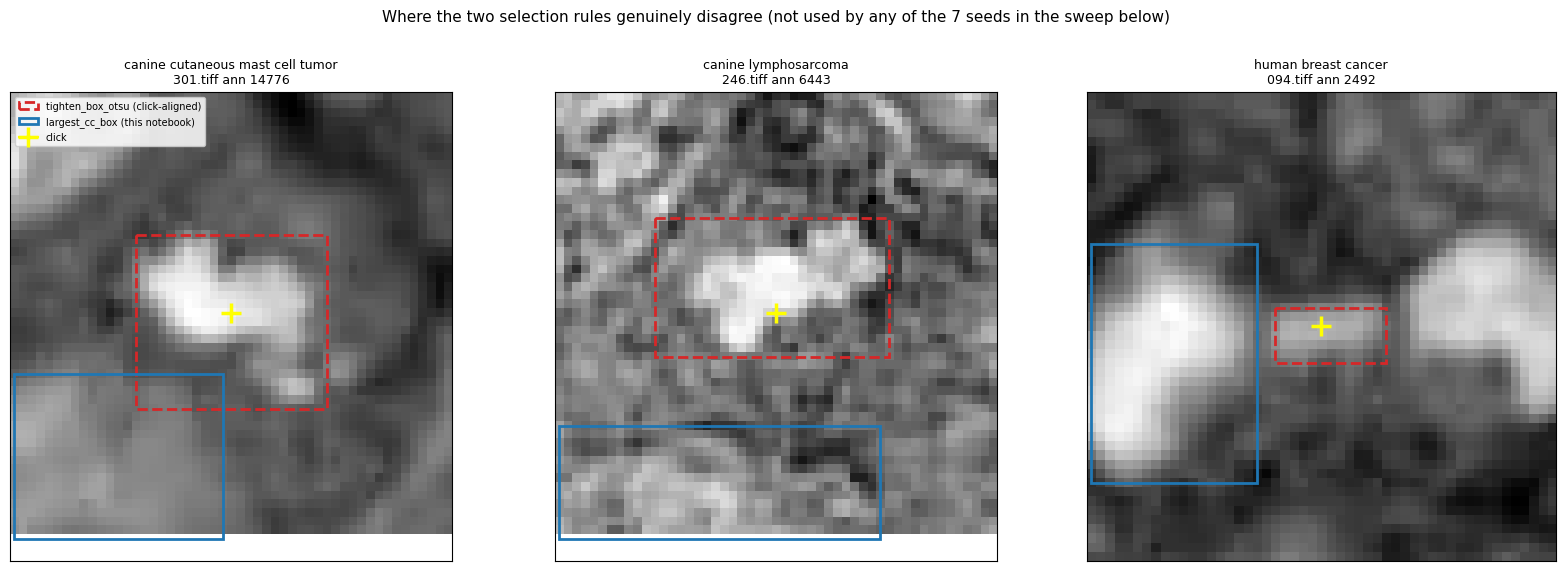

In [9]:
_seen_domains = set()
_chosen = []
for c in divergence_candidates:
    if c['domain'] not in _seen_domains:
        _chosen.append(c)
        _seen_domains.add(c['domain'])
    if len(_chosen) >= 3:
        break
if len(_chosen) < 2:
    _chosen = divergence_candidates[:3]

print(f"{len(divergence_candidates)} pool-wide divergent candidates found across all domains; "
     f"showing {len(_chosen)}.")

if _chosen:
    fig, axes = plt.subplots(1, len(_chosen), figsize=(5.5 * len(_chosen), 5.5))
    axes = np.atleast_1d(axes)
    half = OTSU_WINDOW // 2
    for ax, c in zip(axes, _chosen):
        ax.imshow(c['patch'], cmap='gray')
        ty0, ty1, tx0, tx1 = c['tight_box']
        ax.add_patch(plt.Rectangle((tx0, ty0), tx1 - tx0, ty1 - ty0, edgecolor='#d62728',
                                   facecolor='none', linewidth=2.0, linestyle='--',
                                   label='tighten_box_otsu (click-aligned)'))
        ly0, ly1, lx0, lx1 = c['lcc_box']
        ax.add_patch(plt.Rectangle((lx0, ly0), lx1 - lx0, ly1 - ly0, edgecolor='#1f77b4',
                                   facecolor='none', linewidth=2.0, linestyle='-',
                                   label='largest_cc_box (this notebook)'))
        ax.plot(half, half, marker='+', color='yellow', markersize=14, markeredgewidth=2.5,
               label='click')
        ax.set_title(f"{c['domain']}\n{c['file_name']} ann {c['ann_id']}", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
    axes[0].legend(loc='upper left', fontsize=7, framealpha=0.85)
    fig.suptitle('Where the two selection rules genuinely disagree (not used by any of the 7 '
                'seeds in the sweep below)', fontsize=11, y=1.03)
    fig.tight_layout()
    plt.show()
else:
    print('no divergent candidates found anywhere in the 7 pools -- skipping the figure.')

## Main sweep

One deep candidate pool per domain (`DEEP_FLOOR_Z=-1.5`), built exactly as v2's, with one
change: the seed is drawn via `draw_seed_with_retry` using `largest_cc_box` as the check, and
the template's `base_size` is the tightened box's own (odd) longer side
(`_odd_local(max(y1-y0, x1-x0))`) instead of v2's fixed 51 -- centred on the click, never
recentred to the component's own centroid (mirrors exactly how `tightened_base_size` is used
elsewhere in this repo for the click-aligned variant). Everything downstream -- border padding
(`PAD`, now template-size-dependent), the decoupled NMS radius, chromatin `od` re-ranking (with
its own, template-size-independent padding, see the note above), the one-match-many-`z`
shortcut re-verification, and the `tm_score`/`chromatin_od` arms swept over `Z_LEVELS` -- is
identical in mechanism to v2, just re-run against each domain's own tightened template.

In [10]:
OD_PAD = tm.BASE_SIZE // 2   # 25 -- the chromatin window's OWN padding margin, deliberately
                             # independent of the match template's PAD (see intro markdown):
                             # PAD shrinks below 25 whenever base_size < 51, and reusing it for
                             # the fixed-51px od window would silently NaN border candidates.

all_rows = []
shortcut_checks = []
valid_checks = []
nan_fix_rows = []
seed_info_rows = []
pools = {}   # fn -> bucketed detection frame (score-descending order), for TP/FP views below

for _, row in domain_images.iterrows():
    fn, image_id, domain = row['file_name'], int(row['image_id']), row['tumor_type']
    t0 = time.time()

    rgb = ds.load_roi(f'images/{fn}')
    mpp = ds.roi_mpp(f'images/{fn}')
    match_radius = ev.radius_px(mpp, MATCH_RADIUS_UM)
    nms_radius = ev.radius_px(mpp, NMS_RADIUS_UM)
    hem = ch.to_channel(rgb, CHANNEL)
    gray_inv = ch.to_gray_inverted(rgb)
    H, W = hem.shape[:2]
    gt = ds.image_annotations(annotations, fn)
    gt_mit = gt[gt['category_id'] == ds.MITOTIC]

    pool_seed, flagged = ss.agreement_pool(gt_mit)
    pool_seed = ss.border_filter(pool_seed, BORDER, rgb.shape)
    rng = np.random.default_rng([SEED_INDEX, image_id])

    def _check(cand_row, _gray_inv=gray_inv):
        _patch = tm.read_padded_patch(_gray_inv, float(cand_row['cx']), float(cand_row['cy']),
                                      OTSU_WINDOW)
        if _patch is None:
            return None
        return largest_cc_box(_patch, **LARGEST_CC_KW)

    seed, seed_box, n_retries = draw_seed_with_retry(pool_seed, rng, _check)
    seed_xy = (float(seed['cx']), float(seed['cy']))
    seed_ann_id = int(seed['ann_id'])
    y0, y1, x0, x1 = seed_box
    tightened_size = _odd_local(max(y1 - y0, x1 - x0), minimum=5)

    matches_v2_seed = seed_ann_id == int(v2_seed_by_domain.get(fn, -1))
    if not matches_v2_seed:
        print(f"[{fn}] NOTE: seed differs from v2's ({seed_ann_id} vs "
             f"{v2_seed_by_domain.get(fn)}) -- base_size is not the only changed variable "
             f"for this domain", flush=True)
    if n_retries > 0:
        print(f"[{fn}] NOTE: seed selection needed {n_retries} retry(ies) -- see seed_info "
             f"table for detail", flush=True)

    del gray_inv, _check
    import gc; gc.collect()

    gt_eval = gt[gt['ann_id'] != seed_ann_id].reset_index(drop=True)

    patch73 = tm.read_padded_patch(hem, *seed_xy, CFG.patch_size)
    templates, _ = tm.build_augmentations(patch73, tightened_size, CFG.scales,
                                          CFG.n_angles, CFG.flips)

    # --- pad, match, crop back; valid.all() must hold by construction (v2's Fix 1) ---
    PAD = max((t.shape[0] - 1) // 2 for t in templates)
    hem_p = cv2.copyMakeBorder(hem, PAD, PAD, PAD, PAD, borderType=cv2.BORDER_REPLICATE)
    fused_p, best_p, valid_p = tm.fused_response(hem_p, templates, CFG.scale_normalize, method=METHOD)
    fused = fused_p[PAD:PAD + H, PAD:PAD + W]
    valid = valid_p[PAD:PAD + H, PAD:PAD + W]
    valid_ok = bool(valid.all())
    assert valid_ok, f'{fn}: padding did not make the whole ROI valid (PAD={PAD})'
    valid_checks.append({'file_name': fn, 'domain': domain, 'PAD': PAD, 'base_size': tightened_size,
                         'valid_coverage': float(valid.mean()), 'valid_all': valid_ok})

    med, mad = tm.robust_stats(fused, valid)
    deep_floor = med + DEEP_FLOOR_Z * mad
    centers, scores = tm.extract_peaks(fused, valid, PEAK_MIN_DISTANCE, deep_floor, MAX_PEAKS)

    # --- NMS at the decoupled radius (v2's Fix 2) ---
    keep = nms_by_distance(centers, scores, nms_radius)
    centers, scores = centers[keep], scores[keep]
    ok = np.hypot(centers[:, 0] - seed_xy[0], centers[:, 1] - seed_xy[1]) > CFG.self_hit_radius
    centers, scores = centers[ok], scores[ok]

    pool = pd.DataFrame({'cx': centers[:, 0], 'cy': centers[:, 1], 'score': scores})
    pool['z'] = (pool['score'] - med) / mad

    # --- chromatin od: naive (unpadded) vs. fixed (its OWN padding, OD_PAD, not PAD) ---
    od_naive = cm.score_detections(pool[['cx', 'cy']].copy(), hem)['od']
    hem_od_p = cv2.copyMakeBorder(hem, OD_PAD, OD_PAD, OD_PAD, OD_PAD, borderType=cv2.BORDER_REPLICATE)
    shifted = pool[['cx', 'cy']].assign(cx=pool['cx'] + OD_PAD, cy=pool['cy'] + OD_PAD)
    od_fixed = cm.score_detections(shifted, hem_od_p)['od']
    pool['od'] = od_fixed.to_numpy()
    n_nan_naive = int(od_naive.isna().sum())
    n_nan_fixed = int(pool['od'].isna().sum())
    assert n_nan_fixed == 0, f'{fn}: {n_nan_fixed} candidates still NaN after the od padding fix'
    nan_fix_rows.append({'file_name': fn, 'domain': domain, 'n_pool': len(pool),
                         'od_nan_naive': n_nan_naive, 'od_nan_fixed': n_nan_fixed})
    del hem_od_p

    # --- re-verify the one-match-many-z shortcut at CURRENT_Z ---
    check_cut = med + CURRENT_Z * mad
    c2, s2 = tm.extract_peaks(fused, valid, PEAK_MIN_DISTANCE, check_cut, MAX_PEAKS)
    k2 = nms_by_distance(c2, s2, nms_radius)
    c2 = c2[k2]
    ok2 = np.hypot(c2[:, 0] - seed_xy[0], c2[:, 1] - seed_xy[1]) > CFG.self_hit_radius
    direct = c2[ok2]
    filtered = pool.loc[pool['score'] >= check_cut, ['cx', 'cy']].to_numpy()
    a = direct[np.lexsort((direct[:, 1], direct[:, 0]))] if len(direct) else direct
    b = filtered[np.lexsort((filtered[:, 1], filtered[:, 0]))] if len(filtered) else filtered
    shortcut_ok = (a.shape == b.shape) and bool(np.allclose(a, b))
    assert shortcut_ok, f'{fn}: one-match-many-z shortcut failed at z={CURRENT_Z}'
    shortcut_checks.append({'file_name': fn, 'domain': domain, 'z_checked': CURRENT_Z,
                            'n_direct': len(direct), 'n_filtered': len(filtered), 'passed': shortcut_ok})

    # --- bucket against ground truth (score-descending order) for the TP/FP views below ---
    pool_sorted = pool.sort_values('score', ascending=False).reset_index(drop=True)
    det_out, gt_out = ev.bucket_detections(pool_sorted, gt_eval, match_radius)
    det_out['tumor_type'] = domain
    det_out['file_name'] = fn
    det_out['n_gt_mitotic'] = int((gt_eval['category_id'] == ds.MITOTIC).sum())
    det_out['map_median'] = med
    det_out['mad_scale'] = mad
    pools[fn] = det_out

    seed_info_rows.append({'tumor_type': domain, 'file_name': fn, 'seed_ann_id': seed_ann_id,
                           'n_retries': n_retries, 'base_size': tightened_size,
                           'untightened_51px': tightened_size == tm.BASE_SIZE,
                           'matches_v2_seed': matches_v2_seed})

    ctx = {'file_name': fn, 'image_id': image_id, 'tumor_type': domain,
          'mpp': round(mpp, 4), 'seed_ann_id': seed_ann_id,
          'base_size': tightened_size, 'n_retries': n_retries,
          'map_median': round(med, 5), 'mad_scale': round(mad, 5),
          'deep_floor': round(deep_floor, 5), 'n_pool': len(pool),
          'pad_px': PAD, 'nms_radius_px': round(nms_radius, 3),
          'match_radius_px': round(match_radius, 3)}

    arms = []
    for z in Z_LEVELS:
        cut = med + z * mad
        sub = pool[pool['score'] >= cut]
        limited = bool(cut < deep_floor)
        for axis in AXES:
            arms.append(cp.Arm(
                axis, (lambda d=sub: d), rank_key=AXIS_RANK_KEY[axis], seeded=True, z=z,
                z_dependent=True, floor_limited=limited, nms_radius=None,
                caps=(MAX_PEAKS,), extra={'axis': axis, 'z_cut': round(cut, 5),
                                          'nms_radius_px': round(nms_radius, 3)}))

    got = cp.evaluate_arms(arms, gt_eval, match_radius, roi_shape=rgb.shape, mpp=mpp,
                           budgets=BUDGETS, context=ctx)
    all_rows.append(got)

    vc = det_out['bucket'].value_counts().to_dict()
    print(f"[{fn}] {domain:34s} base_size={tightened_size:2d} n_pool={len(pool):6d} "
         f"valid_all={valid_ok} shortcut_ok={shortcut_ok} od_nan(naive->fixed)={n_nan_naive}->"
         f"{n_nan_fixed} retries={n_retries} TP={vc.get(ev.HUMAN_CORRECT_LABEL, 0)} "
         f"[{time.time() - t0:.0f}s]", flush=True)

    del rgb, hem, hem_p, fused_p, valid_p, fused, valid, patch73, templates
    import gc; gc.collect()

results = pd.concat(all_rows, ignore_index=True)
cp.assert_floor_not_limiting(results)
valid_df = pd.DataFrame(valid_checks)
shortcut_df = pd.DataFrame(shortcut_checks)
nan_fix_df = pd.DataFrame(nan_fix_rows)
seed_info_df = pd.DataFrame(seed_info_rows)

print(f'\ntotal {time.time() - NB_T0:.0f}s, {len(results)} rows (expect 7*9*2*{len(BUDGETS)} = '
     f'{7*9*2*len(BUDGETS)})')
print(f"valid.all(): {valid_df['valid_all'].sum()}/{len(valid_df)} domains")
print(f"shortcut re-verified: {shortcut_df['passed'].sum()}/{len(shortcut_df)} domains")
print(f"od NaN after fix: {(nan_fix_df['od_nan_fixed'] == 0).sum()}/{len(nan_fix_df)} domains "
     f"all zero")
print(f"seed matches v2's: {seed_info_df['matches_v2_seed'].sum()}/{len(seed_info_df)} domains")
print(f"seed needed retries: {(seed_info_df['n_retries'] > 0).sum()}/{len(seed_info_df)} domains")
print(f"untightened (base_size==51): {seed_info_df['untightened_51px'].sum()}/"
     f"{len(seed_info_df)} domains")

[301.tiff] canine cutaneous mast cell tumor   base_size=41 n_pool= 25447 valid_all=True shortcut_ok=True od_nan(naive->fixed)=659->0 retries=0 TP=217 [43s]


[201.tiff] canine lung cancer                 base_size=51 n_pool= 22631 valid_all=True shortcut_ok=True od_nan(naive->fixed)=626->0 retries=0 TP=17 [65s]


[246.tiff] canine lymphosarcoma               base_size=41 n_pool= 30343 valid_all=True shortcut_ok=True od_nan(naive->fixed)=773->0 retries=0 TP=115 [39s]


[459.tiff] canine soft tissue sarcoma         base_size=33 n_pool= 26152 valid_all=True shortcut_ok=True od_nan(naive->fixed)=691->0 retries=0 TP=130 [32s]


[094.tiff] human breast cancer                base_size=25 n_pool= 34573 valid_all=True shortcut_ok=True od_nan(naive->fixed)=824->0 retries=0 TP=81 [56s]


[548.tiff] human melanoma                     base_size=29 n_pool= 29162 valid_all=True shortcut_ok=True od_nan(naive->fixed)=733->0 retries=0 TP=238 [42s]


[402.tiff] human neuroendocrine tumor         base_size=29 n_pool= 32553 valid_all=True shortcut_ok=True od_nan(naive->fixed)=778->0 retries=0 TP=104 [38s]



total 369s, 1008 rows (expect 7*9*2*8 = 1008)
valid.all(): 7/7 domains
shortcut re-verified: 7/7 domains
od NaN after fix: 7/7 domains all zero
seed matches v2's: 7/7 domains
seed needed retries: 0/7 domains
untightened (base_size==51): 1/7 domains


## Deliverable (a): per-domain seed table

Which annotation ended up as the seed, how many retries it took, and the tightened `base_size`
actually used, against v2's fixed 51px everywhere. A domain where `untightened_51px` is `True`
had its largest-CC bbox come out at exactly 51px on the longer side -- effectively no
tightening happened there, and that domain's numbers below should be read as a near-null
control, not as evidence either way about tightening.

In [11]:
seed_info_df

,tumor_type,file_name,seed_ann_id,n_retries,base_size,untightened_51px,matches_v2_seed
0,canine cutaneous mast cell tumor,301.tiff,14969,0,41,False,True
1,canine lung cancer,201.tiff,4457,0,51,True,True
2,canine lymphosarcoma,246.tiff,6548,0,41,False,True
3,canine soft tissue sarcoma,459.tiff,22441,0,33,False,True
4,human breast cancer,094.tiff,2512,0,25,False,True
5,human melanoma,548.tiff,25804,0,29,False,True
6,human neuroendocrine tumor,402.tiff,20254,0,29,False,True


## Persist the run

In [12]:
import pathlib
pathlib.Path('results').mkdir(exist_ok=True)
out_path = 'results/tm_ccoeff_threshold_axis_sweep_largest_cc.csv'
results.to_csv(out_path, index=False)
print('wrote', out_path, results.shape)

wrote results/tm_ccoeff_threshold_axis_sweep_largest_cc.csv (1008, 41)


## Deliverable (c): full recall grid, verdict, and delta vs. v2

`full_list_recall` for the `tm_score` axis (identical to `chromatin_od` on the full list, since
the same candidates just get re-sorted) at every `(domain, z)`.

In [13]:
recall_grid = (results[results['arm'] == 'tm_score']
              .drop_duplicates(['file_name', 'tumor_type', 'z'])
              .pivot(index='tumor_type', columns='z', values='full_list_recall')
              .round(4))
recall_grid

z,-1.0,-0.5,0.0,0.5,1.0,1.5,2.0,2.5,3.0
tumor_type,,,,,,,,,
canine cutaneous mast cell tumor,1.0,1.0,1.0,1.0,1.0,1.0,0.9954,0.9631,0.9124
canine lung cancer,1.0,1.0,1.0,1.0,1.0,1.0,1.0000,1.0000,1.0000
canine lymphosarcoma,1.0,1.0,1.0,1.0,1.0,1.0,1.0000,1.0000,0.9739
canine soft tissue sarcoma,1.0,1.0,1.0,1.0,1.0,1.0,0.9923,0.9769,0.9308
human breast cancer,1.0,1.0,1.0,1.0,1.0,1.0,1.0000,1.0000,1.0000
human melanoma,1.0,1.0,1.0,1.0,1.0,1.0,1.0000,1.0000,0.9958
human neuroendocrine tumor,1.0,1.0,1.0,1.0,1.0,1.0,1.0000,1.0000,1.0000


In [14]:
all_full = bool((recall_grid == 1.0).all().all())
print(f'full recall (1.0000) in every domain at every z in Z_LEVELS: {all_full}')
if not all_full:
    gaps = recall_grid.where(recall_grid < 1.0).stack()
    print(f'{len(gaps)} (domain, z) cells below full recall:')
    print(gaps.sort_values())
else:
    print('every domain reaches full_list_recall == 1.0 at every z in Z_LEVELS.')

le_current = [z for z in Z_LEVELS if z <= CURRENT_Z]
sub_grid = recall_grid[le_current]
full_le_current = bool((sub_grid == 1.0).all().all())
print(f"\nfull recall at every z <= CURRENT_Z ({CURRENT_Z}): {full_le_current}")
sub_grid

full recall (1.0000) in every domain at every z in Z_LEVELS: False
8 (domain, z) cells below full recall:
tumor_type                        z  
canine cutaneous mast cell tumor  3.0    0.9124
canine soft tissue sarcoma        3.0    0.9308
canine cutaneous mast cell tumor  2.5    0.9631
canine lymphosarcoma              3.0    0.9739
canine soft tissue sarcoma        2.5    0.9769
                                  2.0    0.9923
canine cutaneous mast cell tumor  2.0    0.9954
human melanoma                    3.0    0.9958
dtype: float64

full recall at every z <= CURRENT_Z (1.0): True


z,-1.0,-0.5,0.0,0.5,1.0
tumor_type,,,,,
canine cutaneous mast cell tumor,1.0,1.0,1.0,1.0,1.0
canine lung cancer,1.0,1.0,1.0,1.0,1.0
canine lymphosarcoma,1.0,1.0,1.0,1.0,1.0
canine soft tissue sarcoma,1.0,1.0,1.0,1.0,1.0
human breast cancer,1.0,1.0,1.0,1.0,1.0
human melanoma,1.0,1.0,1.0,1.0,1.0
human neuroendocrine tumor,1.0,1.0,1.0,1.0,1.0


In [15]:
old = pd.read_csv('results/tm_ccoeff_threshold_axis_sweep_v2.csv')
old_grid = (old[old['arm'] == 'tm_score']
           .drop_duplicates(['file_name', 'tumor_type', 'z'])
           .pivot(index='tumor_type', columns='z', values='full_list_recall')
           .round(4))

delta = (recall_grid - old_grid.reindex(index=recall_grid.index, columns=recall_grid.columns))
print('recall delta (largest_cc - v2), positive = largest-CC recovers more:')
delta.round(4)

recall delta (largest_cc - v2), positive = largest-CC recovers more:


z,-1.0,-0.5,0.0,0.5,1.0,1.5,2.0,2.5,3.0
tumor_type,,,,,,,,,
canine cutaneous mast cell tumor,0.0,0.0,0.0,0.0,0.0,0.0092,0.0230,0.0414,0.1520
canine lung cancer,0.0,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0000,0.0000
canine lymphosarcoma,0.0,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0087,0.0087
canine soft tissue sarcoma,0.0,0.0,0.0,0.0,0.0,0.0077,0.0154,0.0461,0.0462
human breast cancer,0.0,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0000,0.0000
human melanoma,0.0,0.0,0.0,0.0,0.0,0.0000,0.0042,0.0042,0.0168
human neuroendocrine tumor,0.0,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0000,0.0385


## Deliverable (d): candidate volume and reading depth at `z = CURRENT_Z`, vs. v2

**Read `tm_score` as the headline axis here.** `chromatin_od` in v2's saved CSV was ranked
against the *un-padded* channel (the bug `tp_fp_chromatin_and_raw_score_distribution.ipynb`
found and fixed) -- so v2's `chromatin_od` rows carry hundreds of NaN-`od` candidates sorted to
the list bottom, inflating its own `read_95`/`read_99`/`read_100`. This notebook's
`chromatin_od` uses the fixed, always-non-NaN `od`. `full_list_recall` and `n_detections` are
unaffected by that fix (order-independent), so those two columns are still a clean
tightening-only comparison on both axes; only the `chromatin_od` *read-depth* columns below mix
"tightening" with "the od NaN fix" and should be read with that caveat, not as a clean
tightening effect.

**This is not just an argument -- `201.tiff` (canine lung cancer) proves it directly.** That
domain's largest-CC bbox came out at exactly 51px (see deliverable (a): `untightened_51px=True`,
same seed as v2), so its template is byte-identical to v2's and *nothing* about the search
changed. Its `tm_score` row below reproduces v2 exactly: `n_detections` 16529 = 16529, `read_50`
42 = 42, `read_95` 665 = 665, `n_detections_ratio` = 1.00, `read_95_delta` = 0 -- direct evidence
that this pipeline changes nothing but `base_size` when tightening doesn't fire. Yet its
`chromatin_od` row still moves `read_95` from 16143 (v2) to 801 (this notebook) -- a swing of
-15342 on the one domain where tightening did *literally nothing*. That gap is entirely the
od-NaN fix, not tightening, which is the direct, empirical version of the caveat above rather
than just an assertion of it.

In [16]:
def _snapshot(df, tag):
    d = (df[df['z'] == CURRENT_Z]
        .drop_duplicates(['file_name', 'tumor_type', 'arm'])
        [['tumor_type', 'arm', 'n_detections', 'full_list_recall', 'read_50', 'read_95']]
        .copy())
    d.columns = ['tumor_type', 'arm'] + [f'{c}_{tag}' for c in
                                          ['n_detections', 'full_list_recall', 'read_50', 'read_95']]
    return d

cmp = _snapshot(old, 'v2').merge(_snapshot(results, 'largest_cc'), on=['tumor_type', 'arm'])
cmp['n_detections_ratio'] = (cmp['n_detections_largest_cc'] / cmp['n_detections_v2']).round(2)
cmp['read_95_delta'] = cmp['read_95_largest_cc'] - cmp['read_95_v2']
cmp.sort_values(['arm', 'tumor_type'])

,tumor_type,arm,n_detections_v2,full_list_recall_v2,read_50_v2,read_95_v2,n_detections_largest_cc,full_list_recall_largest_cc,read_50_largest_cc,read_95_largest_cc,n_detections_ratio,read_95_delta
1,canine cutaneous mast cell tumor,chromatin_od,21871,1.0,221.0,9096.0,22227,1.0,198.0,7345.0,1.02,-1751.0
3,canine lung cancer,chromatin_od,16529,1.0,24.0,16143.0,16529,1.0,27.0,801.0,1.00,-15342.0
5,canine lymphosarcoma,chromatin_od,25786,1.0,158.0,3800.0,26677,1.0,170.0,2819.0,1.03,-981.0
7,canine soft tissue sarcoma,chromatin_od,15216,1.0,112.0,9167.0,20892,1.0,128.0,10236.0,1.37,1069.0
9,human breast cancer,chromatin_od,21143,1.0,81.0,1316.0,26147,1.0,92.0,1559.0,1.24,243.0
11,human melanoma,chromatin_od,15809,1.0,181.0,3833.0,20810,1.0,205.0,4628.0,1.32,795.0
13,human neuroendocrine tumor,chromatin_od,20884,1.0,156.0,4262.0,27280,1.0,196.0,5373.0,1.31,1111.0
0,canine cutaneous mast cell tumor,tm_score,21871,1.0,531.0,8906.0,22227,1.0,345.0,9433.0,1.02,527.0
2,canine lung cancer,tm_score,16529,1.0,42.0,665.0,16529,1.0,42.0,665.0,1.00,0.0
4,canine lymphosarcoma,tm_score,25786,1.0,137.0,2629.0,26677,1.0,134.0,1912.0,1.03,-717.0


## Deliverable (e): TP vs. FP score distributions on this arm's pool, at `z = 1.0`

Same style, subsampling and colours as `tp_fp_score_distribution.ipynb` /
`tp_fp_chromatin_and_raw_score_distribution.ipynb`, on this notebook's own (tightened-template)
deep pool. Every TP and every look-alike FP is plotted in full; unannotated FP is subsampled to
`FP_SUBSAMPLE_CAP` per domain with a freshly-seeded `rng` in each of the three cells below (so
all three views show the same subsample per domain -- a deliberate choice, differing slightly
from `tp_fp_chromatin_and_raw_score_distribution.ipynb`, which reuses one `rng` across its two
figures and so shows different subsamples per panel there).

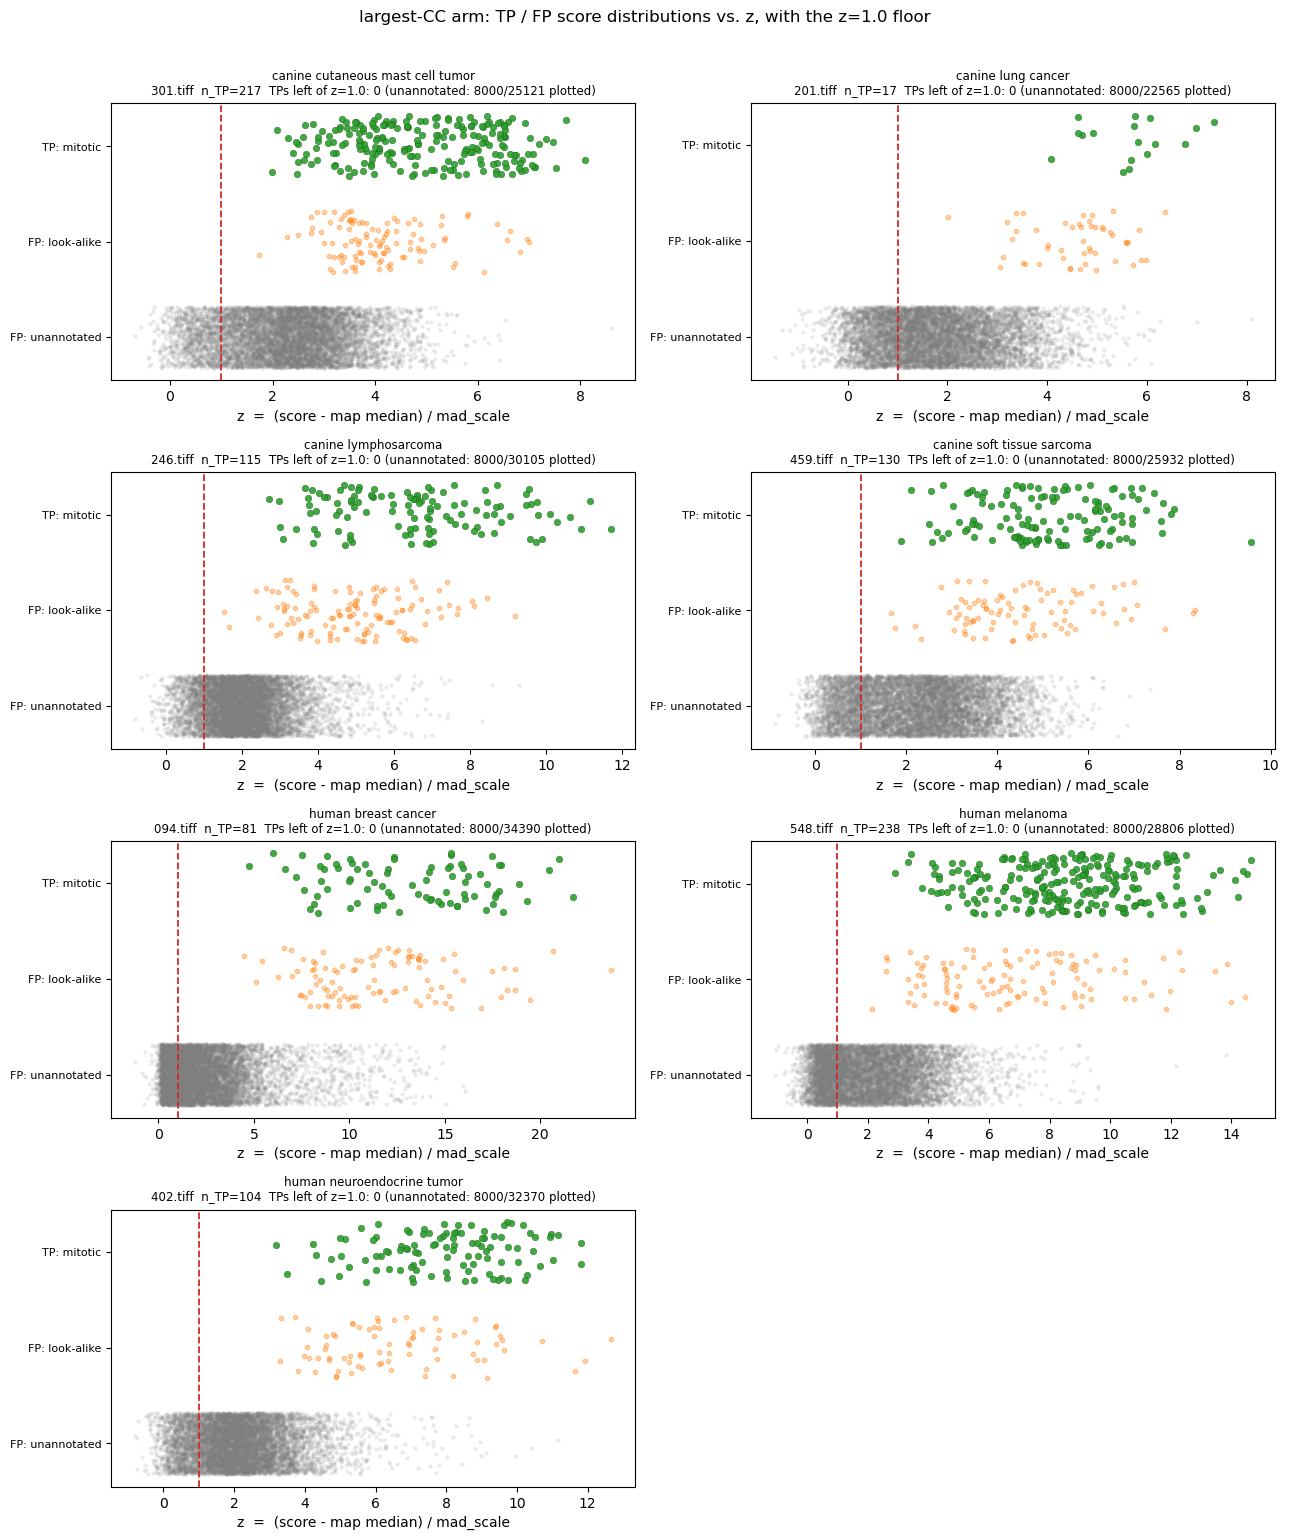

In [17]:
domains_by_file = domain_images.set_index('file_name')['tumor_type'].to_dict()
files = list(domain_images.sort_values('tumor_type')['file_name'])
n = len(files)
ncols = 2
nrows = -(-n // ncols)
JITTER = 0.32

rng = np.random.default_rng(RNG_SEED)
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.8 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, fn in zip(axes, files):
    domain = domains_by_file[fn]
    det_out = pools[fn]
    n_sub_note = []
    for bucket in (ev.NON_HUMAN_FINDINGS, ev.HUMAN_REJECTED_LABEL, ev.HUMAN_CORRECT_LABEL):
        sub = det_out[det_out['bucket'] == bucket]
        if bucket == ev.NON_HUMAN_FINDINGS and len(sub) > FP_SUBSAMPLE_CAP:
            idx = rng.choice(len(sub), size=FP_SUBSAMPLE_CAP, replace=False)
            sub = sub.iloc[idx]
            n_sub_note.append(f"unannotated: {FP_SUBSAMPLE_CAP}/{len(det_out[det_out['bucket']==bucket])} plotted")
        lane = BUCKET_LANE[bucket]
        y = lane + rng.uniform(-JITTER, JITTER, size=len(sub))
        ax.scatter(sub['z'], y, color=BUCKET_COLOR[bucket], **STYLE[bucket])

    ax.axvline(CURRENT_Z, color='#d62728', linestyle='--', linewidth=1.3)
    n_tp = int((det_out['bucket'] == ev.HUMAN_CORRECT_LABEL).sum())
    n_tp_cut = int(((det_out['bucket'] == ev.HUMAN_CORRECT_LABEL) & (det_out['z'] < CURRENT_Z)).sum())
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['FP: unannotated', 'FP: look-alike', 'TP: mitotic'], fontsize=8)
    ax.set_xlabel('z  =  (score - map median) / mad_scale')
    note = f" ({'; '.join(n_sub_note)})" if n_sub_note else ''
    ax.set_title(f"{domain}\n{fn}  n_TP={n_tp}  TPs left of z=1.0: {n_tp_cut}{note}", fontsize=8.5)

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle('largest-CC arm: TP / FP score distributions vs. z, with the z=1.0 floor', y=1.01, fontsize=12)
fig.tight_layout()
plt.show()

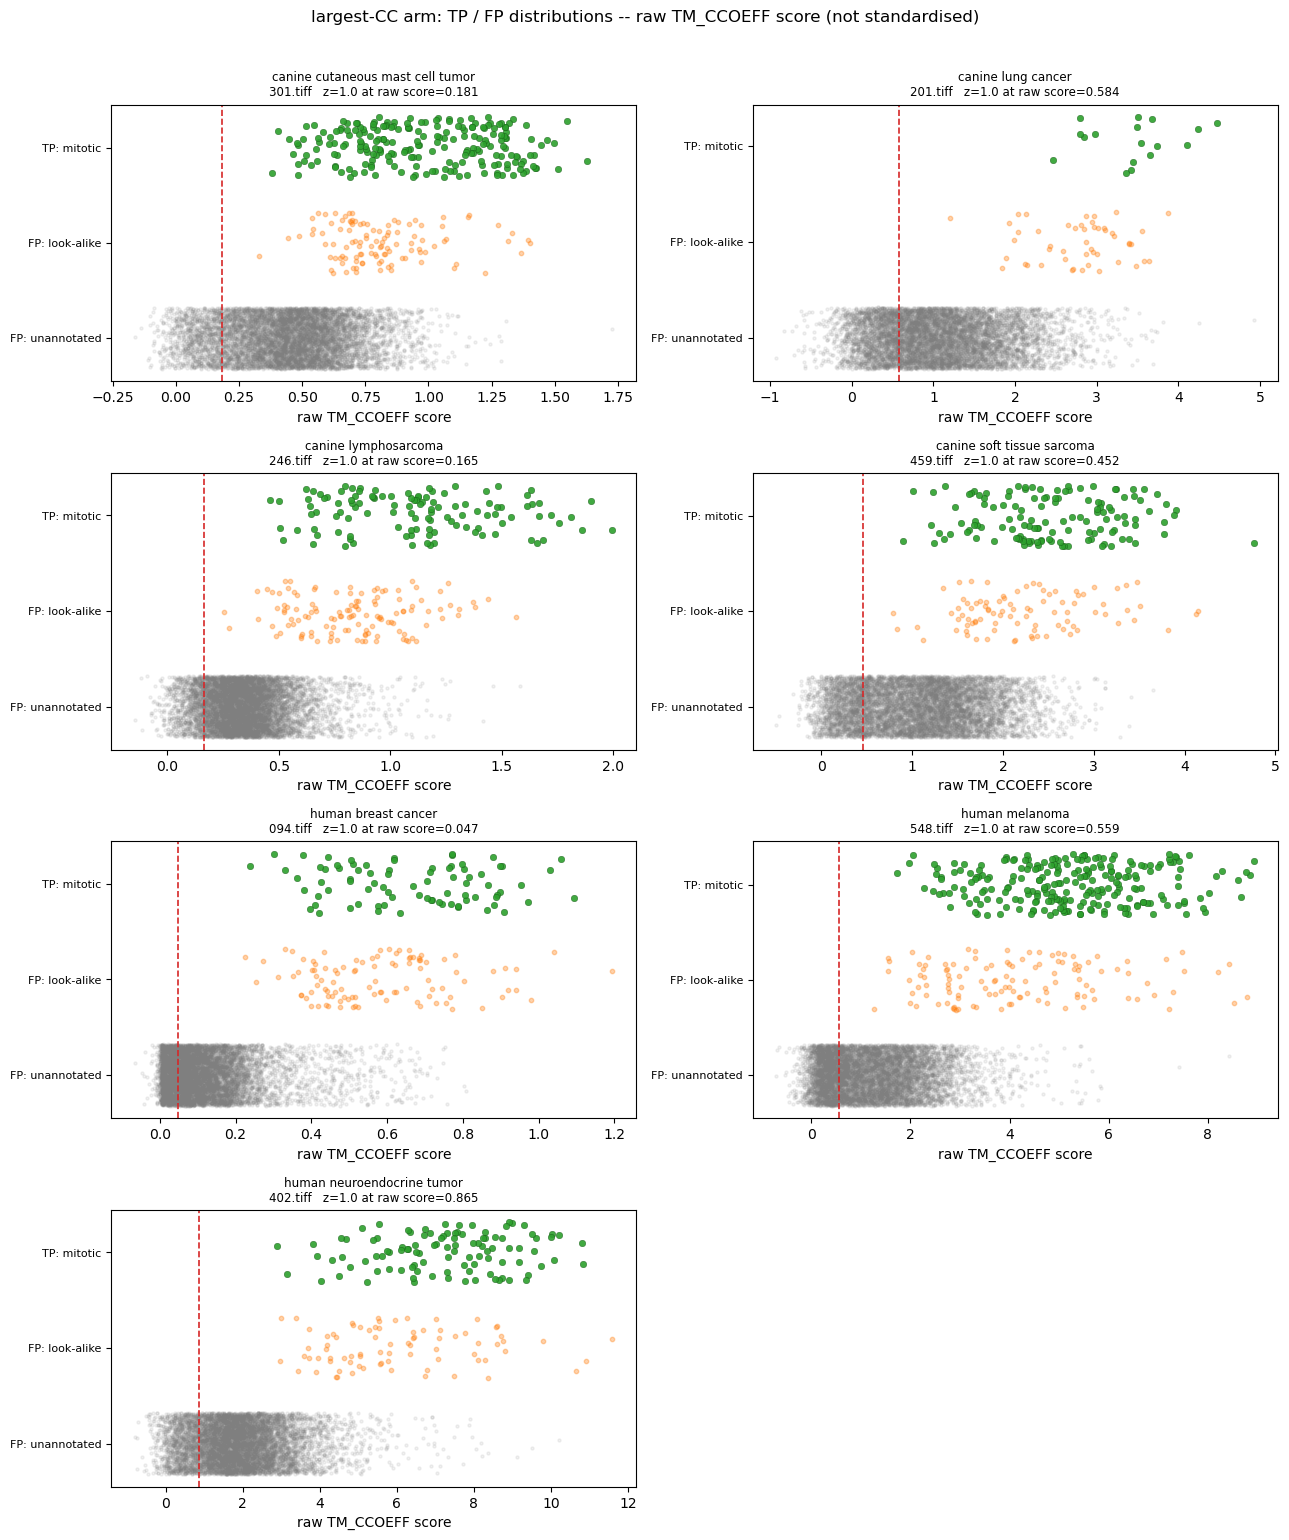

In [18]:
rng = np.random.default_rng(RNG_SEED)
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.8 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, fn in zip(axes, files):
    domain = domains_by_file[fn]
    det_out = pools[fn]
    med = det_out['map_median'].iloc[0]
    mad = det_out['mad_scale'].iloc[0]
    cut_raw = med + CURRENT_Z * mad
    for bucket in (ev.NON_HUMAN_FINDINGS, ev.HUMAN_REJECTED_LABEL, ev.HUMAN_CORRECT_LABEL):
        sub = det_out[det_out['bucket'] == bucket]
        if bucket == ev.NON_HUMAN_FINDINGS and len(sub) > FP_SUBSAMPLE_CAP:
            idx = rng.choice(len(sub), size=FP_SUBSAMPLE_CAP, replace=False)
            sub = sub.iloc[idx]
        lane = BUCKET_LANE[bucket]
        y = lane + rng.uniform(-JITTER, JITTER, size=len(sub))
        ax.scatter(sub['score'], y, color=BUCKET_COLOR[bucket], **STYLE[bucket])

    ax.axvline(cut_raw, color='#d62728', linestyle='--', linewidth=1.2)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['FP: unannotated', 'FP: look-alike', 'TP: mitotic'], fontsize=8)
    ax.set_xlabel('raw TM_CCOEFF score')
    ax.set_title(f"{domain}\n{fn}   z=1.0 at raw score={cut_raw:.3f}", fontsize=8.5)

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle('largest-CC arm: TP / FP distributions -- raw TM_CCOEFF score (not standardised)',
            y=1.01, fontsize=12)
fig.tight_layout()
plt.show()

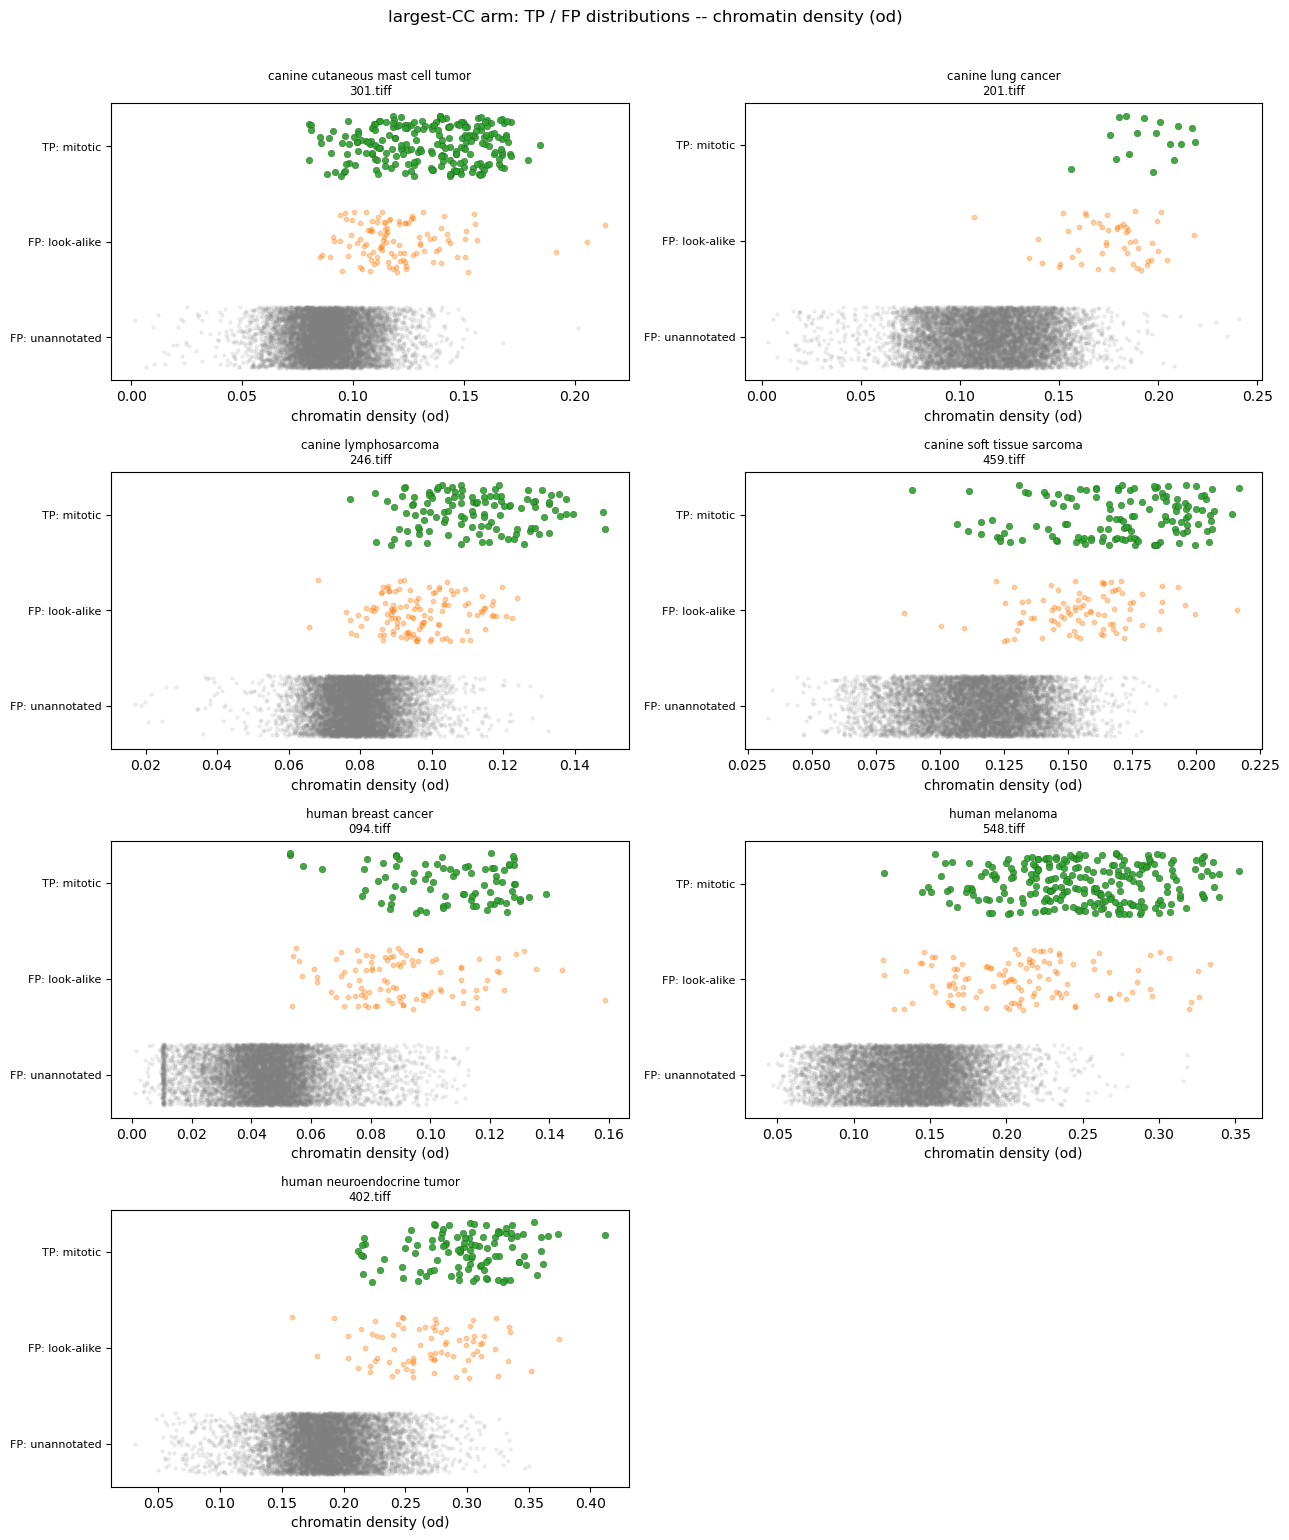

In [19]:
rng = np.random.default_rng(RNG_SEED)
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.8 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, fn in zip(axes, files):
    domain = domains_by_file[fn]
    det_out = pools[fn]
    for bucket in (ev.NON_HUMAN_FINDINGS, ev.HUMAN_REJECTED_LABEL, ev.HUMAN_CORRECT_LABEL):
        sub = det_out[det_out['bucket'] == bucket]
        if bucket == ev.NON_HUMAN_FINDINGS and len(sub) > FP_SUBSAMPLE_CAP:
            idx = rng.choice(len(sub), size=FP_SUBSAMPLE_CAP, replace=False)
            sub = sub.iloc[idx]
        lane = BUCKET_LANE[bucket]
        y = lane + rng.uniform(-JITTER, JITTER, size=len(sub))
        ax.scatter(sub['od'], y, color=BUCKET_COLOR[bucket], **STYLE[bucket])

    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['FP: unannotated', 'FP: look-alike', 'TP: mitotic'], fontsize=8)
    ax.set_xlabel('chromatin density (od)')
    ax.set_title(f"{domain}\n{fn}", fontsize=8.5)

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle('largest-CC arm: TP / FP distributions -- chromatin density (od)', y=1.01, fontsize=12)
fig.tight_layout()
plt.show()

## Deliverable (f): FP/TP separability, this arm vs. v2

Same statistic as `tp_fp_chromatin_and_raw_score_distribution.ipynb`: for each domain and
signal, the fraction of `non_human_findings` (unannotated FP) at or above the domain's
lowest-scoring TP on that signal -- lower is cleaner separation. Computed fresh on this arm's
pool below. `v2_reference` is hardcoded from that notebook's own executed output (it was never
persisted to a CSV, so this is transcribed from its printed `sep_table`, not recomputed here) --
**both its `chromatin_od` numbers and this arm's use the fixed (padded) od**, so the
`chromatin_od` column of this specific comparison is apples-to-apples; only deliverable (d)'s
*read-depth* numbers carry the od-fix confound, not this separability statistic.

**A second, different confound applies to this table, and it is worth naming before reading the
deltas below.** `frac_fp_in_tp_range` is `#{FP >= lowest TP} / #{all unannotated FP in the deep
pool}`. This arm's deep pools are larger than v2's `z=1.0` candidate counts in every genuinely
tightened domain (e.g. 25447-34573 here vs. v2's 15216-25786), and the deep-pool floor
(`med + DEEP_FLOOR_Z*mad`) is computed from each arm's own, different response-map statistics --
so a larger low-score FP denominator alone can shrink this fraction with no real change in
discrimination. It is not the *whole* story (mast cell tumor has `n_detections_ratio` 1.02 --
barely more candidates -- yet its `tm_score` separability still improves by 0.18; breast cancer
has ratio 1.24 but its delta is +0.008, essentially flat), so some of the movement below is
real. But checked against `read_95_delta` (deliverable (d)'s confound-free reading-depth number
on the same `tm_score` axis) domain by domain: the two metrics agree in sign (both improve or
both worsen) on only 3 of the 6 genuinely-tightened domains (lymphosarcoma, melanoma,
neuroendocrine tumor) and disagree on the other 3 (mast cell tumor, soft tissue sarcoma, breast
cancer -- where separability says "better" but reading depth says "worse", or vice versa on
breast). Read the separability deltas below with that tension stated, not as "largest-CC
separates more cleanly in most domains" -- the metric that would need to move together with it
to support that reading does not consistently move the same way.

In [20]:
sep_rows = []
for fn in files:
    det_out = pools[fn]
    tp = det_out[det_out['bucket'] == ev.HUMAN_CORRECT_LABEL]
    fpu = det_out[det_out['bucket'] == ev.NON_HUMAN_FINDINGS]
    if len(tp) == 0:
        continue
    tp_z_min = float(tp['z'].min())
    tp_score_min = float(tp['score'].min())
    tp_od_min = float(tp['od'].min())
    frac_z = float((fpu['z'] >= tp_z_min).mean())
    frac_score = float((fpu['score'] >= tp_score_min).mean())
    frac_od = float((fpu['od'] >= tp_od_min).mean())
    sep_rows.append({'tumor_type': domains_by_file[fn], 'file_name': fn, 'n_tp': len(tp),
                     'frac_fp_in_tp_range__tm_score': round(frac_score, 4),
                     'frac_fp_in_tp_range__tm_z': round(frac_z, 4),
                     'frac_fp_in_tp_range__chromatin_od': round(frac_od, 4),
                     'better_signal': 'chromatin_od' if frac_od < frac_score else 'tm_score'})

sep_table = pd.DataFrame(sep_rows).sort_values('tumor_type')
assert np.allclose(sep_table['frac_fp_in_tp_range__tm_score'],
                   sep_table['frac_fp_in_tp_range__tm_z']), \
    'raw score and z disagreed on separability -- the monotone-transform argument would be wrong'
print('raw-score and z separability match exactly on every domain (as they must): confirmed.')
sep_table

raw-score and z separability match exactly on every domain (as they must): confirmed.


,tumor_type,file_name,n_tp,frac_fp_in_tp_range__tm_score,frac_fp_in_tp_range__tm_z,frac_fp_in_tp_range__chromatin_od,better_signal
0,canine cutaneous mast cell tumor,301.tiff,217,0.6212,0.6212,0.7309,tm_score
1,canine lung cancer,201.tiff,17,0.0272,0.0272,0.0340,tm_score
2,canine lymphosarcoma,246.tiff,115,0.2005,0.2005,0.5961,tm_score
3,canine soft tissue sarcoma,459.tiff,130,0.5880,0.5880,0.8926,tm_score
4,human breast cancer,094.tiff,81,0.1125,0.1125,0.2746,tm_score
5,human melanoma,548.tiff,238,0.2637,0.2637,0.7181,tm_score
6,human neuroendocrine tumor,402.tiff,104,0.1629,0.1629,0.2075,tm_score


In [21]:
# Transcribed verbatim from tp_fp_chromatin_and_raw_score_distribution.ipynb's own executed
# output (v2's 51px-everywhere template, fixed/padded od) -- never persisted to a CSV on disk.
v2_reference = pd.DataFrame([
    {'tumor_type': 'canine cutaneous mast cell tumor', 'file_name': '301.tiff', 'n_tp': 217,
     'frac_fp_in_tp_range__tm_score': 0.8018, 'frac_fp_in_tp_range__chromatin_od': 0.7488},
    {'tumor_type': 'canine lung cancer', 'file_name': '201.tiff', 'n_tp': 17,
     'frac_fp_in_tp_range__tm_score': 0.0272, 'frac_fp_in_tp_range__chromatin_od': 0.0340},
    {'tumor_type': 'canine lymphosarcoma', 'file_name': '246.tiff', 'n_tp': 115,
     'frac_fp_in_tp_range__tm_score': 0.3000, 'frac_fp_in_tp_range__chromatin_od': 0.5642},
    {'tumor_type': 'canine soft tissue sarcoma', 'file_name': '459.tiff', 'n_tp': 130,
     'frac_fp_in_tp_range__tm_score': 0.6889, 'frac_fp_in_tp_range__chromatin_od': 0.8714},
    {'tumor_type': 'human breast cancer', 'file_name': '094.tiff', 'n_tp': 81,
     'frac_fp_in_tp_range__tm_score': 0.1042, 'frac_fp_in_tp_range__chromatin_od': 0.2925},
    {'tumor_type': 'human melanoma', 'file_name': '548.tiff', 'n_tp': 238,
     'frac_fp_in_tp_range__tm_score': 0.5282, 'frac_fp_in_tp_range__chromatin_od': 0.6929},
    {'tumor_type': 'human neuroendocrine tumor', 'file_name': '402.tiff', 'n_tp': 104,
     'frac_fp_in_tp_range__tm_score': 0.1813, 'frac_fp_in_tp_range__chromatin_od': 0.5923},
]).sort_values('tumor_type').reset_index(drop=True)

sep_cmp = sep_table[['tumor_type', 'file_name', 'n_tp', 'frac_fp_in_tp_range__tm_score',
                    'frac_fp_in_tp_range__chromatin_od']].reset_index(drop=True)
sep_cmp = sep_cmp.merge(v2_reference, on=['tumor_type', 'file_name'],
                        suffixes=('_largest_cc', '_v2'))
sep_cmp['delta_tm_score'] = (sep_cmp['frac_fp_in_tp_range__tm_score_largest_cc']
                             - sep_cmp['frac_fp_in_tp_range__tm_score_v2']).round(4)
sep_cmp['delta_chromatin_od'] = (sep_cmp['frac_fp_in_tp_range__chromatin_od_largest_cc']
                                 - sep_cmp['frac_fp_in_tp_range__chromatin_od_v2']).round(4)
sep_cmp

,tumor_type,file_name,n_tp_largest_cc,frac_fp_in_tp_range__tm_score_largest_cc,frac_fp_in_tp_range__chromatin_od_largest_cc,n_tp_v2,frac_fp_in_tp_range__tm_score_v2,frac_fp_in_tp_range__chromatin_od_v2,delta_tm_score,delta_chromatin_od
0,canine cutaneous mast cell tumor,301.tiff,217,0.6212,0.7309,217,0.8018,0.7488,-0.1806,-0.0179
1,canine lung cancer,201.tiff,17,0.0272,0.0340,17,0.0272,0.0340,0.0000,0.0000
2,canine lymphosarcoma,246.tiff,115,0.2005,0.5961,115,0.3000,0.5642,-0.0995,0.0319
3,canine soft tissue sarcoma,459.tiff,130,0.5880,0.8926,130,0.6889,0.8714,-0.1009,0.0212
4,human breast cancer,094.tiff,81,0.1125,0.2746,81,0.1042,0.2925,0.0083,-0.0179
5,human melanoma,548.tiff,238,0.2637,0.7181,238,0.5282,0.6929,-0.2645,0.0252
6,human neuroendocrine tumor,402.tiff,104,0.1629,0.2075,104,0.1813,0.5923,-0.0184,-0.3848


## Closing summary

**Coincidence caveat, restated.** This run's 7 seeds were all cases where `tighten_box_otsu`
(production's click-aligned rule) and `largest_cc_box` (this notebook's rule) agree exactly --
an outcome the pool-wide coincidence rates themselves predict (product 0.8699 against an
observed 7/7), not a surprise -- so nothing below speaks to "largest-CC vs. click-aligned"
specifically. It speaks cleanly to "size-tightened-via-Otsu+largest-CC vs. v2's raw, fixed 51px
box", since v2 applied zero tightening on every domain and 6 of these 7 domains' templates did
shrink (25-41px; only `201.tiff`/canine lung cancer stayed at 51px, an untightened null
control -- see deliverable (d) for what that domain proves directly).

**The verdict, stated plainly:**

* **Recall: unchanged at the operating point, strictly better beyond it.** Identical to v2 --
  `full_list_recall == 1.0` in every domain at every `z <= 1.0` -- and at `z` in `{1.5, 2.0,
  2.5, 3.0}`, where v2 starts losing recall in several domains, largest-CC's recall delta is
  `>= 0` in every single `(domain, z)` cell measured, up to +0.152 (canine cutaneous mast cell
  tumor at `z=3.0`). Tightening never costs recall and recovers some at aggressive cutoffs
  v2 doesn't reach at `CURRENT_Z=1.0` anyway.
* **Candidate volume: tightening consistently *lengthens* the list, not shortens it.**
  `n_detections_ratio` (largest-CC / v2, at `z=1.0`) is `>= 1.0` in all 7 domains and reaches
  1.02-1.37 in the 6 domains that actually tightened. A smaller template has a broader,
  less-selective correlation response (more of the map clears the same per-map `z` cut), so
  candidate volume goes *up*, not down -- the opposite of what "a tighter template" might
  suggest. This is the one clean, confound-free effect in this run (order- and denominator-
  independent), and it is unambiguous.
* **Reading depth (`tm_score`, the confound-free axis -- see deliverable (d) for why
  `chromatin_od`'s is not): mixed, no consistent direction.** `read_95_delta` ranges from +1416
  (soft tissue sarcoma, worse) to -1547 (neuroendocrine tumor, better), with no domain property
  visible in this run that predicts the sign.
* **TP/FP separability: apparent improvement on most domains, but not corroborated by reading
  depth.** See deliverable (f)'s `sep_cmp` table and its stated caveat: the separability
  fraction and `read_95_delta` (both computed on `tm_score`) agree in sign on only 3 of 6
  tightened domains. Read the separability numbers as suggestive, not as independent
  confirmation that largest-CC discriminates TP from FP better -- the metric most likely to
  share that confound (a larger, differently-normalised deep pool) is exactly the one driving
  this table.

**Net read.** The one unambiguous, confound-free effect largest-CC tightening has in this run
is that it does not cost recall and it does increase candidate volume. Reading depth and
separability move in domain-specific and partly-contradictory directions, so this run does not
support a general claim that largest-CC tightening makes the list shorter or the ranking
cleaner -- only that it is safe on recall and comes at some reading-depth cost on several
domains. `201.tiff`'s untightened null control (identical seed, identical 51px template)
reproduces v2's `tm_score` numbers exactly, which is the direct evidence that everything
reported above is attributable to `base_size` and nothing else crept into the comparison.